In [1]:
!pip install kagglehub -q

import kagglehub
path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")
print("Path to dataset files:", path)

import os
for root, dirs, files in os.walk(path):
    print(root, files[:5])

100%|██████████| 5.23M/5.23M [00:00<00:00, 60.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/faviovaz/marketing-ab-testing/versions/1
/root/.cache/kagglehub/datasets/faviovaz/marketing-ab-testing/versions/1 ['marketing_AB.csv']


In [2]:
import pandas as pd
import sqlite3

df = pd.read_csv(f'{path}/marketing_AB.csv')
print(df.shape)
df.head()

(588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [3]:
# SQLite
conn = sqlite3.connect(':memory:')
df.to_sql('campaigns', conn, index=False, if_exists='replace')

query1 = """
SELECT
    "test group" AS group_name,
    COUNT(*) AS total_users,
    SUM(CASE WHEN converted = 1 THEN 1 ELSE 0 END) AS conversions,
    ROUND(100.0 * SUM(CASE WHEN converted = 1 THEN 1 ELSE 0 END) / COUNT(*), 3) AS conversion_rate_pct
FROM campaigns
GROUP BY "test group"
"""
result1 = pd.read_sql_query(query1, conn)
print(result1)

  group_name  total_users  conversions  conversion_rate_pct
0         ad       564577        14423                2.555
1        psa        23524          420                1.785


In [4]:
query2 = """
SELECT
    "most ads hour" AS hour,
    "test group" AS group_name,
    COUNT(*) AS users,
    ROUND(100.0 * SUM(CASE WHEN converted = 1 THEN 1 ELSE 0 END) / COUNT(*), 3) AS conversion_rate_pct
FROM campaigns
GROUP BY "most ads hour", "test group"
ORDER BY hour
"""
result2 = pd.read_sql_query(query2, conn)
print(result2.head(20))

    hour group_name  users  conversion_rate_pct
0      0         ad   5309                1.921
1      0        psa    227                0.000
2      1         ad   4615                1.343
3      1        psa    187                0.000
4      2         ad   5152                0.757
5      2        psa    181                0.000
6      3         ad   2590                1.042
7      3        psa     89                1.124
8      4         ad    694                1.585
9      4        psa     28                0.000
10     5         ad    742                2.156
11     5        psa     23                0.000
12     6         ad   1985                2.317
13     6        psa     83                0.000
14     7         ad   6168                1.848
15     7        psa    237                0.844
16     8         ad  16968                1.986
17     8        psa    659                1.062
18     9         ad  29802                1.953
19     9        psa   1202              

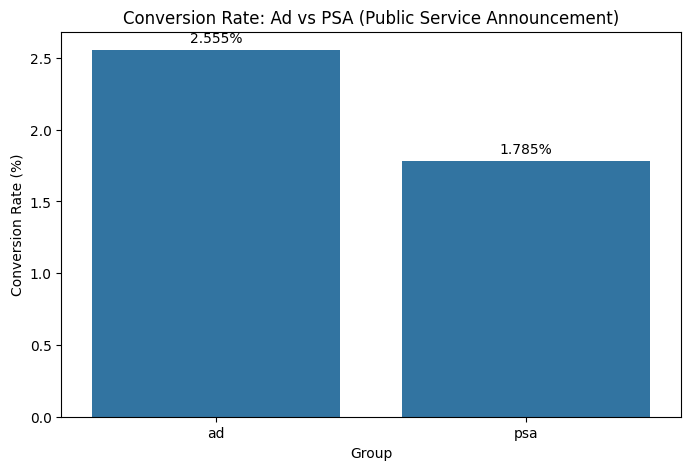

Overall conversion rate by group
  group_name  total_users  conversions  conversion_rate_pct
0         ad       564577        14423                2.555
1        psa        23524          420                1.785


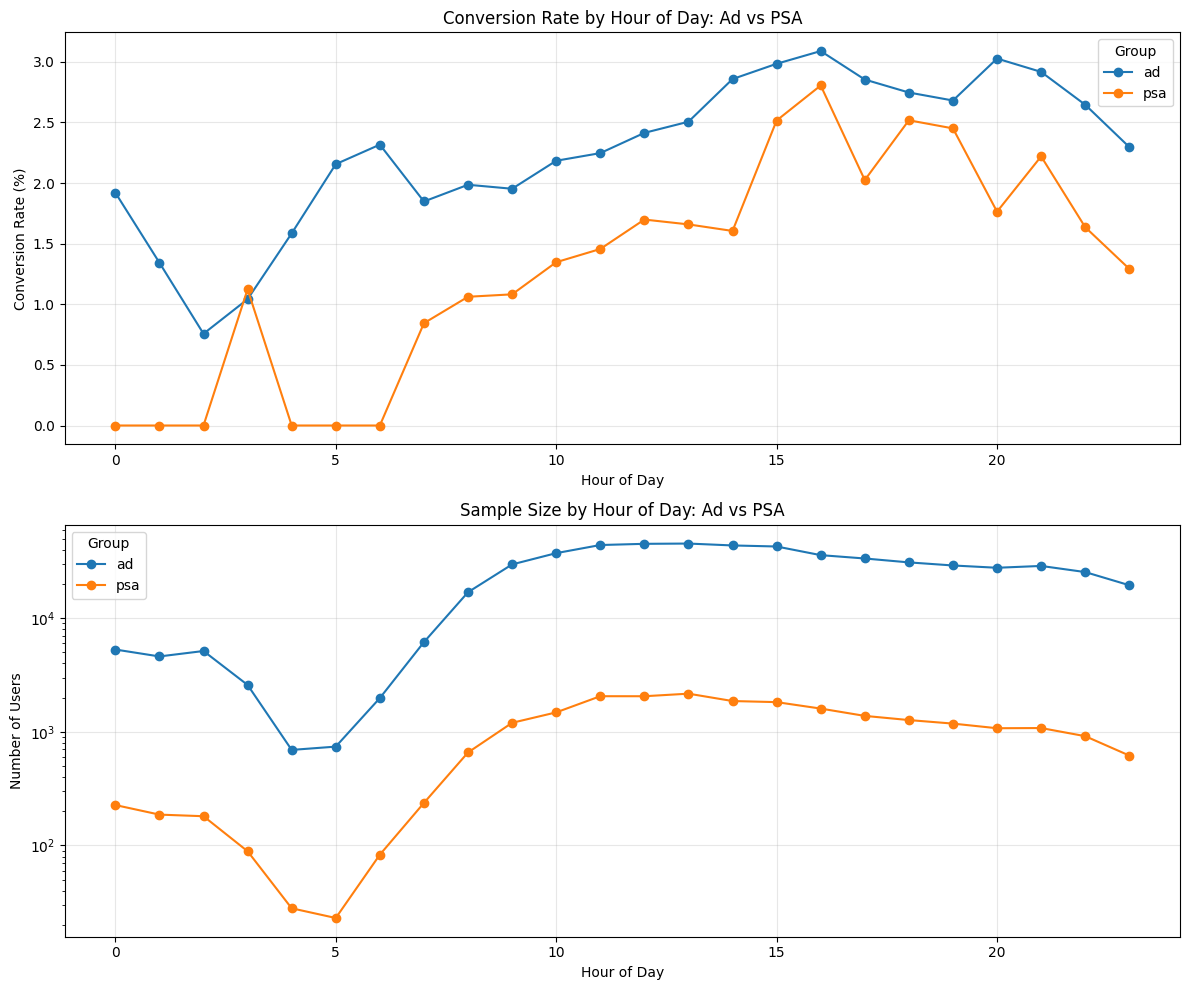

 Conversion rate by hour (%) 
group_name     ad    psa
hour                    
0           1.921  0.000
1           1.343  0.000
2           0.757  0.000
3           1.042  1.124
4           1.585  0.000
5           2.156  0.000
6           2.317  0.000
7           1.848  0.844
8           1.986  1.062
9           1.953  1.082
10          2.184  1.347
11          2.247  1.456
12          2.414  1.699
13          2.506  1.659
14          2.858  1.605
15          2.984  2.516
16          3.089  2.805
17          2.854  2.025
18          2.747  2.518
19          2.681  2.451
20          3.027  1.764
21          2.917  2.220
22          2.646  1.636
23          2.297  1.292

 Sample size by hour 
group_name     ad   psa
hour                   
0            5309   227
1            4615   187
2            5152   181
3            2590    89
4             694    28
5             742    23
6            1985    83
7            6168   237
8           16968   659
9           29802  1202
10       

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=result1, x='group_name', y='conversion_rate_pct')
plt.title('Conversion Rate: Ad vs PSA (Public Service Announcement)')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Group')
for i, row in result1.iterrows():
    plt.text(i, row['conversion_rate_pct'] + 0.05, f"{row['conversion_rate_pct']}%", ha='center')
plt.show()

print("Overall conversion rate by group")
print(result1.to_string())

pivot = result2.pivot(index='hour', columns='group_name', values='conversion_rate_pct')
pivot_n = result2.pivot(index='hour', columns='group_name', values='users')

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

pivot.plot(marker='o', ax=axes[0])
axes[0].set_title('Conversion Rate by Hour of Day: Ad vs PSA')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].legend(title='Group')
axes[0].grid(alpha=0.3)

pivot_n.plot(marker='o', ax=axes[1])
axes[1].set_title('Sample Size by Hour of Day: Ad vs PSA')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Users')
axes[1].legend(title='Group')
axes[1].grid(alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(" Conversion rate by hour (%) ")
print(pivot.round(3).to_string())
print("\n Sample size by hour ")
print(pivot_n.to_string())

print("\n Hours where PSA sample size < 50 (unreliable conversion rate) ")
unreliable = pivot_n[pivot_n['psa'] < 50]
print(unreliable.to_string())

In [9]:
from scipy.stats import chi2_contingency
import numpy as np

contingency = pd.crosstab(df['test group'], df['converted'])
print("Contingency table")
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.10f}")

df_clean = df[~df['most ads hour'].isin([4, 5])].copy()

contingency_clean = pd.crosstab(df_clean['test group'], df_clean['converted'])
chi2_clean, p_value_clean, dof_clean, expected_clean = chi2_contingency(contingency_clean)

print(" After excluding hours 4 & 5 (unreliable sample) ")
print(contingency_clean)
print(f"Chi-square statistic: {chi2_clean:.2f}")
print(f"P-value: {p_value_clean:.10f}")

rate_ad = df_clean[df_clean['test group']=='ad']['converted'].mean() * 100
rate_psa = df_clean[df_clean['test group']=='psa']['converted'].mean() * 100
print(f"\nConversion rate (ad): {rate_ad:.3f}%")
print(f"Conversion rate (psa): {rate_psa:.3f}%")

from statsmodels.stats.proportion import proportion_effectsize

p1 = rate_ad / 100
p2 = rate_psa / 100
effect_size = proportion_effectsize(p1, p2)
print(f"Effect size (Cohen's h): {effect_size:.4f}")
print("(0.2=small, 0.5=medium, 0.8=large — this tells you if the difference matters practically, not just statistically)")

Contingency table
converted    False  True 
test group               
ad          550154  14423
psa          23104    420

Chi-square statistic: 54.01
P-value: 0.0000000000
 After excluding hours 4 & 5 (unreliable sample) 
converted    False  True 
test group               
ad          548745  14396
psa          23053    420
Chi-square statistic: 53.55
P-value: 0.0000000000

Conversion rate (ad): 2.556%
Conversion rate (psa): 1.789%
Effect size (Cohen's h): 0.0528
(0.2=small, 0.5=medium, 0.8=large — this tells you if the difference matters practically, not just statistically)


In [10]:
from statsmodels.stats.power import NormalIndPower

analysis = NormalIndPower()
required_n = analysis.solve_power(effect_size=0.0528, alpha=0.05, power=0.8, ratio=1)
print(f"Minimum sample size needed per group (80% power, equal groups): {required_n:.0f}")

actual_ratio = 550154 / 23104
required_n_ratio = analysis.solve_power(effect_size=0.0528, alpha=0.05, power=0.8, ratio=actual_ratio)
print(f"Minimum PSA-group sample size needed (matching actual {actual_ratio:.1f}:1 ratio): {required_n_ratio:.0f}")
print(f"Actual PSA group sample size: 23524")

Minimum sample size needed per group (80% power, equal groups): 5631
Minimum PSA-group sample size needed (matching actual 23.8:1 ratio): 2934
Actual PSA group sample size: 23524


In [11]:
avg_order_value = 50
cost_per_ad_impression = 0.05

rate_ad_actual = 0.02556
rate_psa_actual = 0.01789
incremental_rate = rate_ad_actual - rate_psa_actual

total_ad_users = 564577
incremental_conversions = incremental_rate * total_ad_users
incremental_revenue = incremental_conversions * avg_order_value

total_ad_impressions = df[df['test group']=='ad']['total ads'].sum()
total_ad_cost = total_ad_impressions * cost_per_ad_impression

print(f"Incremental conversion rate: {incremental_rate:.4%}")
print(f"Estimated incremental conversions: {incremental_conversions:.0f}")
print(f"Estimated incremental revenue: ${incremental_revenue:,.2f}")
print(f"Estimated total ad impressions: {total_ad_impressions:,}")
print(f"Estimated total ad cost: ${total_ad_cost:,.2f}")
print(f"Estimated ROI: {(incremental_revenue - total_ad_cost) / total_ad_cost:.2%}")

Incremental conversion rate: 0.7670%
Estimated incremental conversions: 4330
Estimated incremental revenue: $216,515.28
Estimated total ad impressions: 14,014,701
Estimated total ad cost: $700,735.05
Estimated ROI: -69.10%


In [12]:
breakeven_order_value = total_ad_cost / incremental_conversions
print(f"Break-even average order value (at $0.05/impression): ${breakeven_order_value:.2f}")

breakeven_cost_per_impression = incremental_revenue / total_ad_impressions
print(f"Break-even cost per impression (at $50 order value): ${breakeven_cost_per_impression:.4f}")

Break-even average order value (at $0.05/impression): $161.82
Break-even cost per impression (at $50 order value): $0.0154
